In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# set Pandas Display Options
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.precision', 2)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [4]:
load_path = "/home/hass/Documents/Learning/Salifort-Motors-Capstone-Project/00-data_cleaned/"
save_path = "/home/hass/Documents/Learning/Salifort-Motors-Capstone-Project/00-data_cleaned/"

In [5]:
# Load dataset into a dataframe
df = pd.read_csv(load_path + "data_cleaned_Ol_NoFE_AllFeat.csv")          # 11991 rows, all data including outliers
#df1  = pd.read_csv(load_path + "data_cleaned_NoOl_NoFE_AllFeat.csv")      # 11167 rows, no outliers (mostly from tenure)

# Display first few rows of the dataframe

df.head()

,satisfaction,last_eval,number_project,avg_mnth_hrs,tenure,accident,left,promotion,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
pd.options.display.float_format = '{:.2f}'.format
counts = df['left'].value_counts()
perc = df['left'].value_counts(normalize=True)*100

summary_table = pd.DataFrame({"Counts " : counts,
                              "Percentage " : perc})

summary_table


,Counts,Percentage
left,,
0,10000,83.40
1,1991,16.60


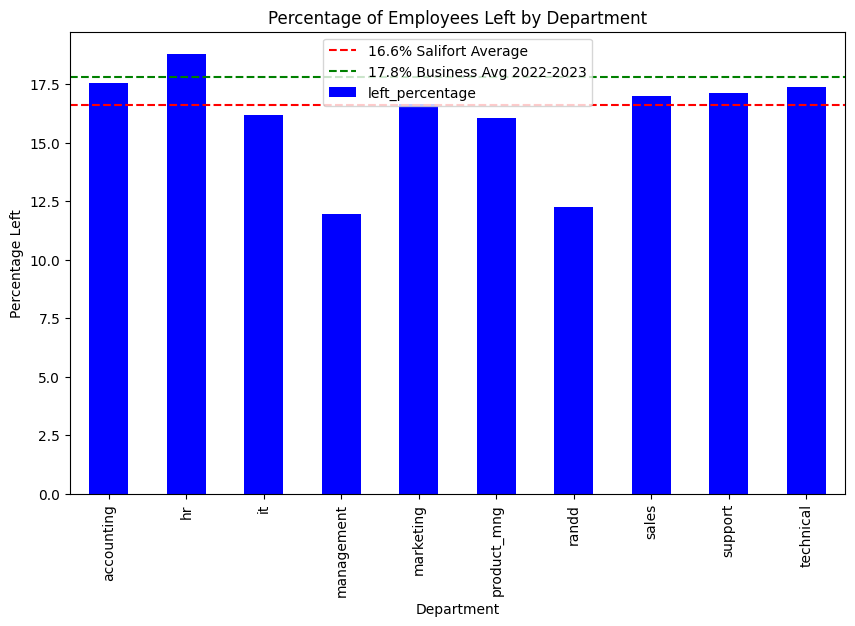

In [7]:
# Calculate counts and percentages by department
dept_counts = df.groupby('dept')['left'].value_counts().unstack().fillna(0)
dept_counts['total'] = dept_counts.sum(axis=1)
dept_counts['left_percentage'] = (dept_counts[1] / dept_counts['total']) * 100

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
dept_counts['left_percentage'].plot(kind='bar', color='blue', ax=ax)

# Add lines at 16.6% and 2.8%
ax.axhline(y=16.6, color='red', linestyle='--', label='16.6% Salifort Average')
ax.axhline(y=17.8, color='green', linestyle='--', label='17.8% Business Avg 2022-2023')

# Add labels and legend
ax.set_xlabel('Department')
ax.set_ylabel('Percentage Left')
ax.set_title('Percentage of Employees Left by Department')
ax.legend()

# Show the plot
plt.show()


In [8]:
df_left_1 = df[df['left'] == 1]
left_1 = df_left_1.groupby(['dept', 'salary']).size().unstack()

total_df = df.groupby(['dept', 'salary']).size().unstack()

df_percentage = (left_1 / total_df) * 100

# Reset index to bring 'department' back as a column
df_percentage.reset_index(inplace=True)

# Print the result
print(df_percentage)

salary         dept  high   low  medium
0        accounting  4.76 19.93   17.94
1                hr  7.89 20.95   17.98
2                it  5.63 18.28   15.62
3        management  0.78 23.02   11.24
4         marketing  4.84 24.52   10.96
5       product_mng  7.69 17.20   16.15
6             randd  6.38 15.84    9.54
7             sales  5.06 20.54   15.11
8           support  3.97 22.03   14.01
9         technical  6.02 20.91   15.11


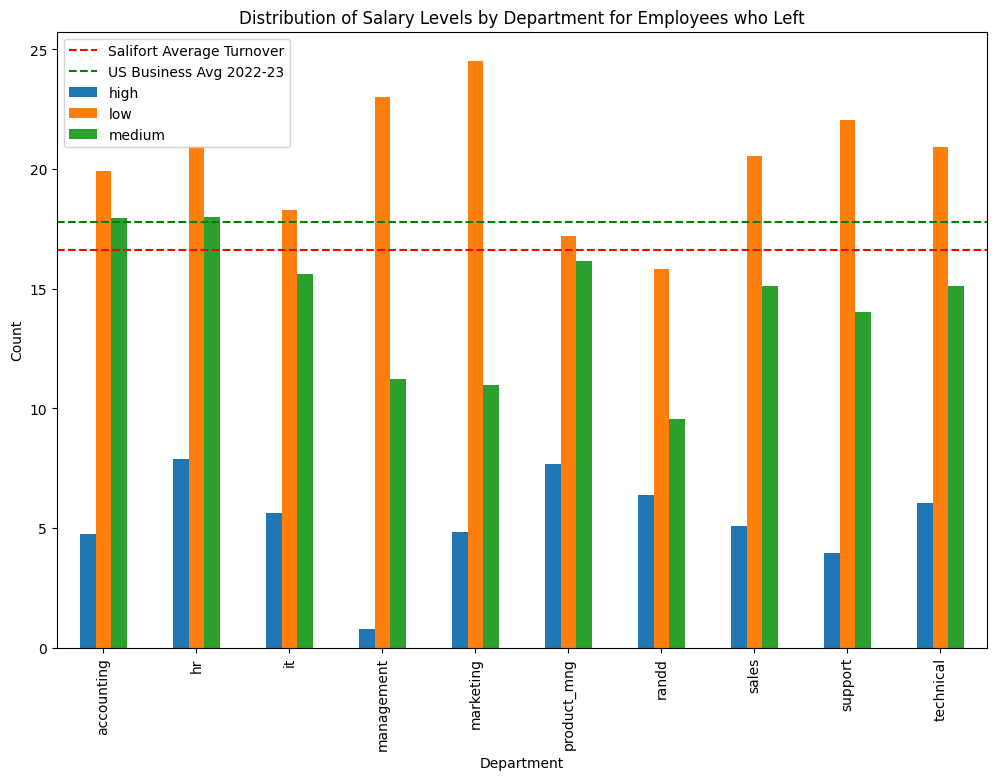

In [9]:

# Plot the bar graph
fig, ax = plt.subplots(figsize=(12, 8))

# Plot bars for each salary level in each department
df_percentage.plot(kind='bar', x = 'dept', stacked=False, ax=ax)

# Add lines at 16.6% and 2.8%
ax.axhline(y=16.6, color='red', linestyle='--', label='Salifort Average Turnover')
ax.axhline(y=17.8, color='green', linestyle='--', label='US Business Avg 2022-23')

# Add labels and legend
ax.set_xlabel('Department')
ax.set_ylabel('Count')
ax.set_title('Distribution of Salary Levels by Department for Employees who Left')
ax.legend()

# Show the plot
plt.show()